In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from src import *

In [4]:
Y = list(range(2**9))

def dice_loss(y, y_hat):
    if y == 0:
        if y_hat == 0:
            return 0
        else:
            return 1
    else:
        return 1 - 2 * (int2img(y) * int2img(y_hat)).sum() / (int2img(y).sum() + int2img(y_hat).sum() + 1)

AllDiceLosses = np.array([np.array([dice_loss(y1, y2) for y2 in Y]) for y1 in Y])

In [52]:
def diff_loss(y, y_hat):
    return np.abs(int2img(y).astype("int8") - int2img(y_hat).astype("int8")).sum() / 9

AllDiffLosses = np.array([np.array([diff_loss(y1, y2) for y2 in Y]) for y1 in Y])

# Probabilitiy distributions


In [59]:
# random input probabilitiy
Px = np.random.RandomState(42).rand(2**9)
Px /= Px.sum()

# Py = np.array([sp.special.softmax(5 * np.random.RandomState(x).beta(0.01, 1.0, 2**9)) for x in range(2**9)])
Py = np.array([np.random.RandomState(x).randint(2**9) for x in range(2**9)])  # random "correct" image
Py = np.array([1-AllDiffLosses[y] for y in Py])
K = 10
Py = np.array([sp.special.expit(np.random.RandomState(x).normal(K*sp.special.logit(Py[x]), K*0.5)) for x in range(2**9)])
Py = np.array([Py[x] / Py[x].sum() for x in range(2**9)])

In [60]:
# estimated marginal probabilities
hatPyi = np.array([np.array([int2img(y) * Py[x,y] for y in range(2**9)]).sum(0) for x in range(2**9)])

# image-level output probability derived from pixel-level probabilities
# Py = [np.array([np.where(int2img(y), Pyi[x], 1 - Pyi[x]).prod() for y in range(2**9)]) for x in range(2**9)]

## Example

X = 100


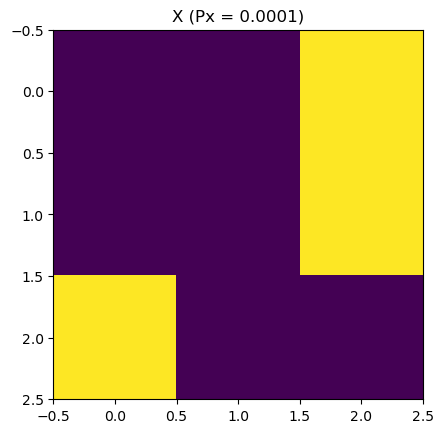

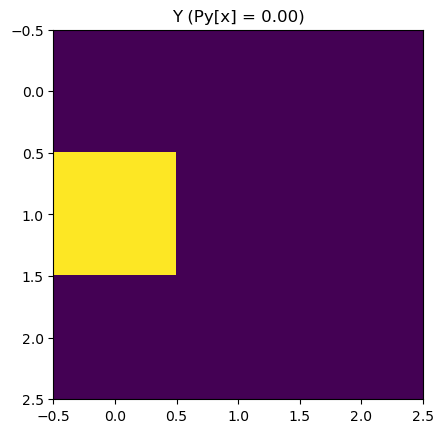

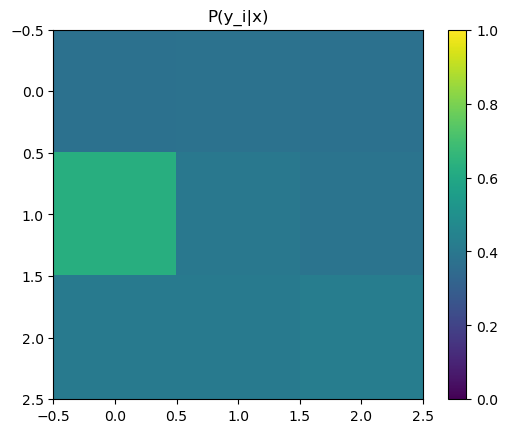

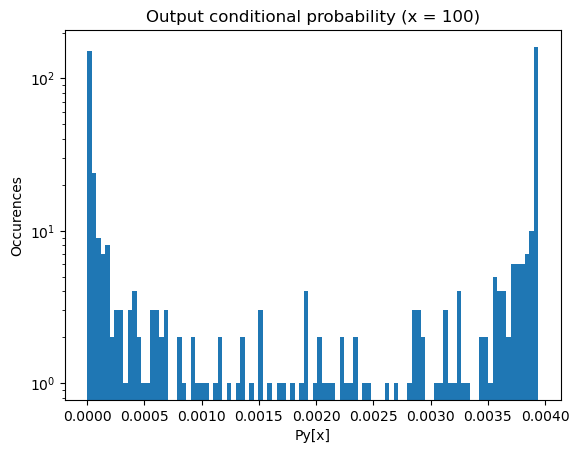

X = 247


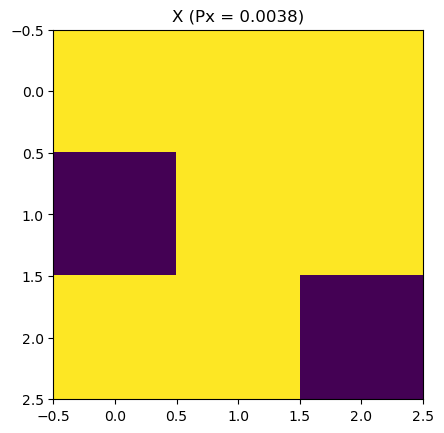

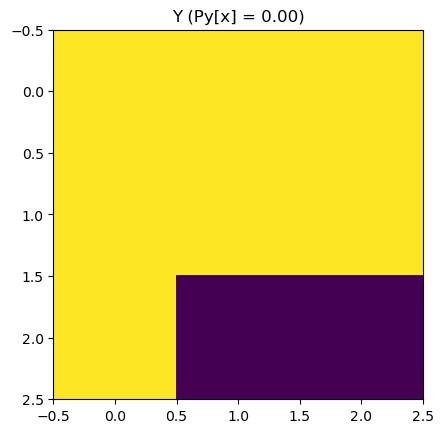

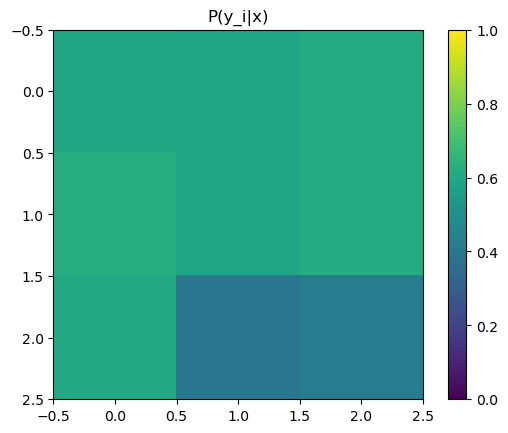

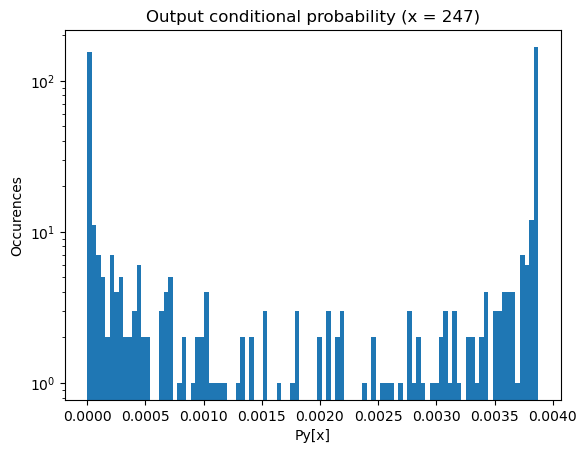

X = 232


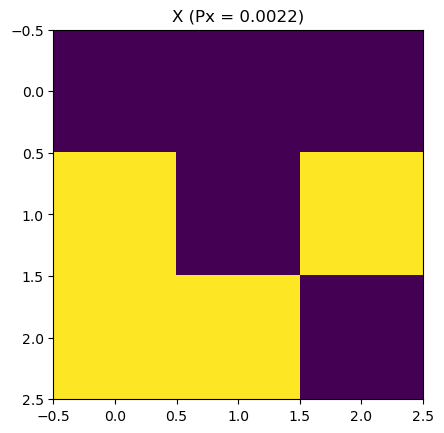

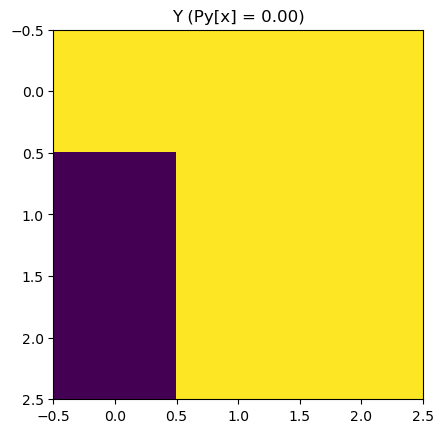

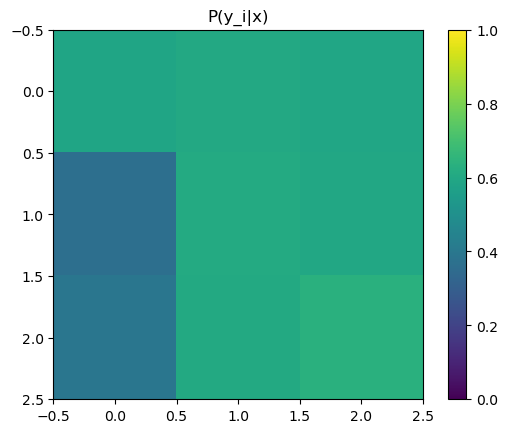

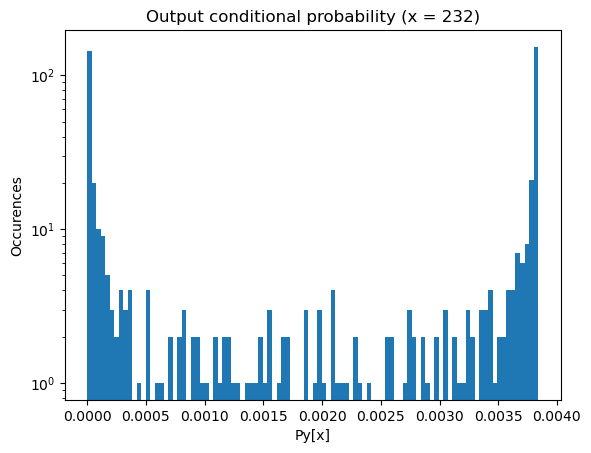

X = 75


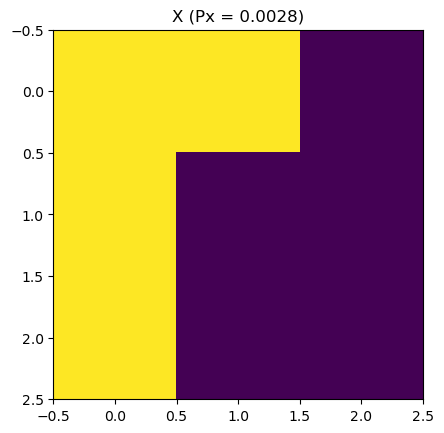

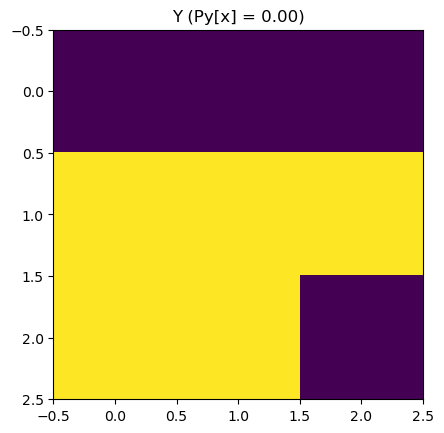

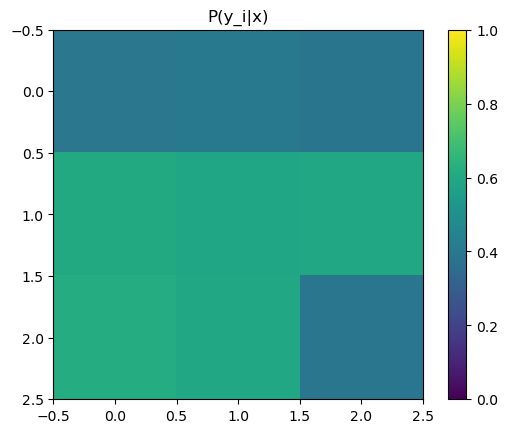

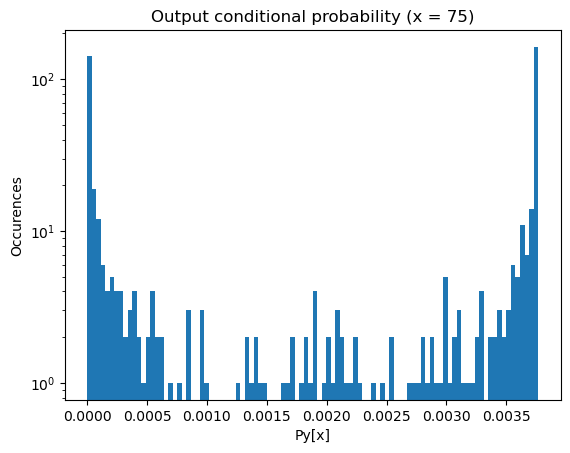

X = 249


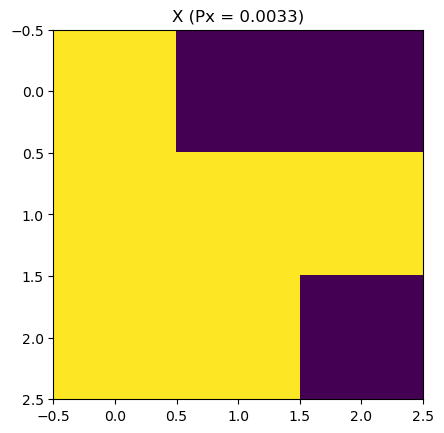

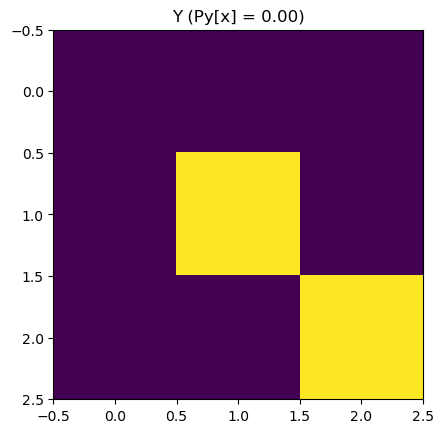

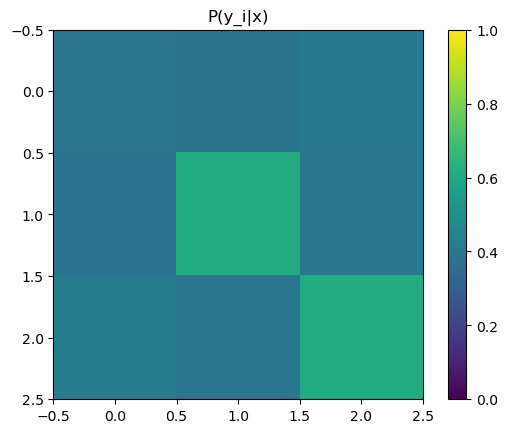

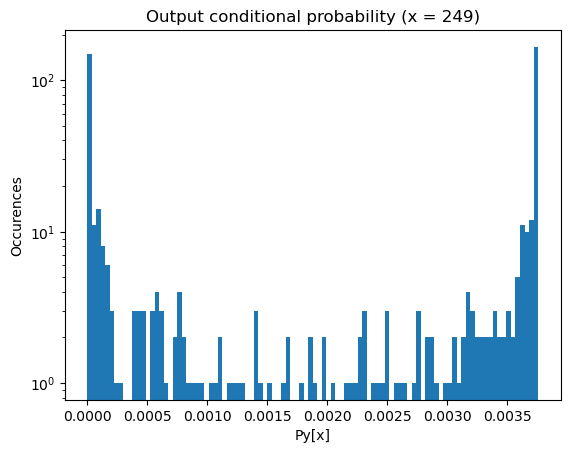

In [61]:
for i in range(5):
    x = np.random.choice(2**9, p=Px)
    # y = np.random.choice(2**9, p=Py[x])
    y = np.argmax(Py[x])

    print(f"X = {x}")

    plt.imshow(int2img(x), vmin=0, vmax=1)
    plt.title(f'X (Px = {Px[x]:.4f})')
    plt.show()

    plt.imshow(int2img(y), vmin=0, vmax=1)
    plt.title(f'Y (Py[x] = {Py[x,y]:.2f})')
    plt.show()

    plt.imshow(hatPyi[x], vmin=0, vmax=1)
    plt.colorbar()
    plt.title('P(y_i|x)')
    plt.show()

    plt.hist(Py[x], bins=100)
    # plt.xlim(0,1)
    plt.title(f"Output conditional probability (x = {x})")
    plt.xlabel("Py[x]")
    plt.ylabel("Occurences")
    plt.yscale('log')
    plt.show()

# Models based on the estimated marginal probabilities


## Pixel-wise model (accuracy)

The model constructs the prediction by applying a threshold (0.5) at the predicted probabilities.

In [62]:
def h(x):
    yhat_img = (hatPyi[x] > 0.5).astype("uint8")
    yhat = np.sum(2**np.arange(9) * yhat_img.reshape(-1))
    return yhat

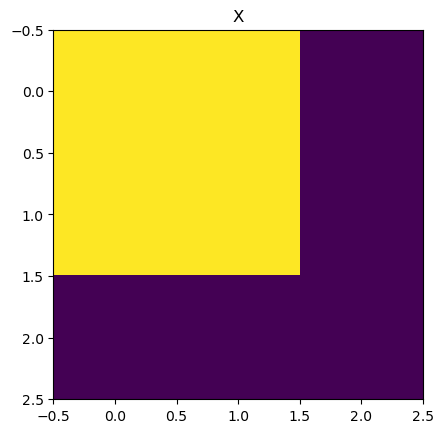

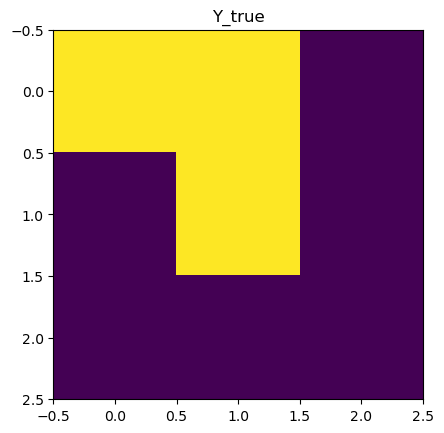

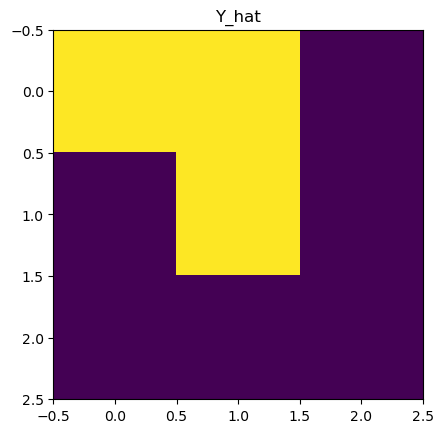

In [63]:
## EXAMPLE
x = np.random.choice(2**9, p=Px)
y_true = np.argmax(Py[x])
y_hat = h(x)

plt.imshow(int2img(x), vmin=0, vmax=1)
plt.title('X')
plt.show()
plt.imshow(int2img(y_true))
plt.title('Y_true')
plt.show()

plt.imshow(int2img(y_hat))
plt.title('Y_hat')
plt.show()

### Losses

In [64]:
# for plot_loss in [plot_01_loss, plot_accuracy_loss, plot_voldiff_loss, plot_quadvoldiff_loss, plot_dice_loss]:
#     plot_loss(h, Px, Py, hatPyi)

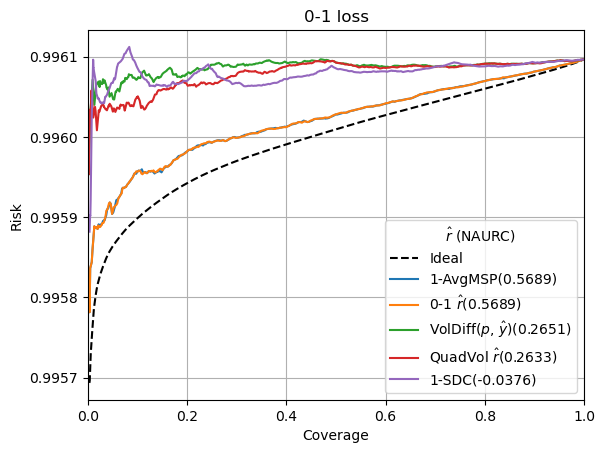

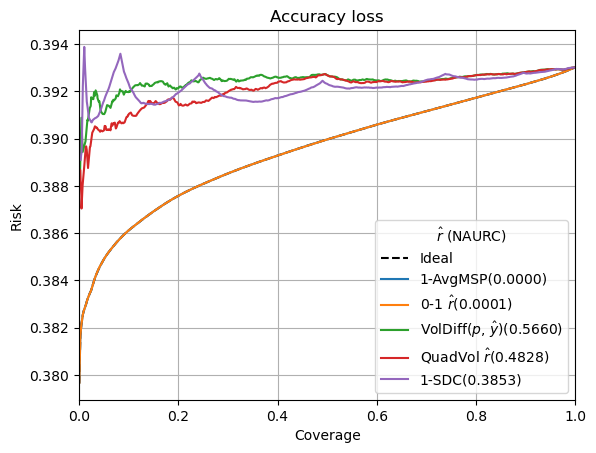

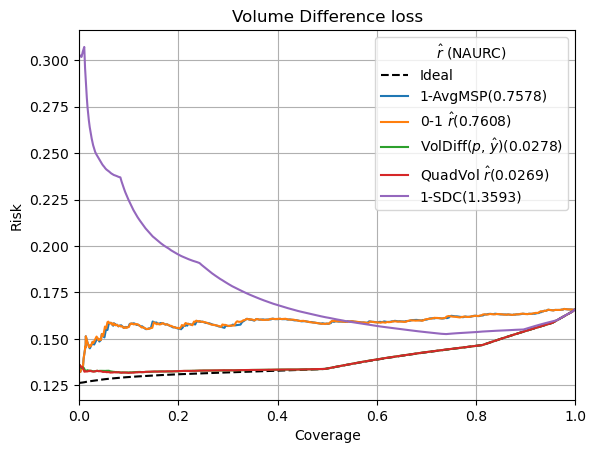

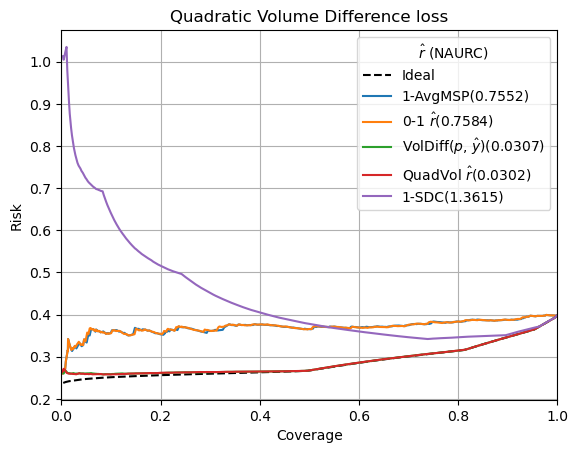

In [65]:
for plot_rc in [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]:
    plot_rc(h, Px, Py, hatPyi)

## Max Dice model

The model is constructed as it were trained to minimize the dice loss. Its output is the segmentation that maximizes $\sum_y \hat{p}(y|x) DSC(y,\hat{y})$.

In [120]:
Y = list(range(2**9))

hatPy = [np.array([np.where(int2img(y), pyi, 1 - pyi).prod() for y in np.arange(2**9)]) for pyi in hatPyi]

y_true = lambda x: np.argmax(Py[x])

# precompute the risk associated to each y given x
Ryhat_dice = np.array([AllDiceLosses @ hatPy[x] for x in range(2**9)])  # Ry_dice[x,y] $\gets r_dice(x|h(x) = y)$

In [121]:
# model minimizes the DICE loss, i.e., picks the target with the lowest
# predicted conditional risk y^ = argmin_y r^(x|h(x)=y)
h = lambda x: np.argmin(Ryhat_dice[x])

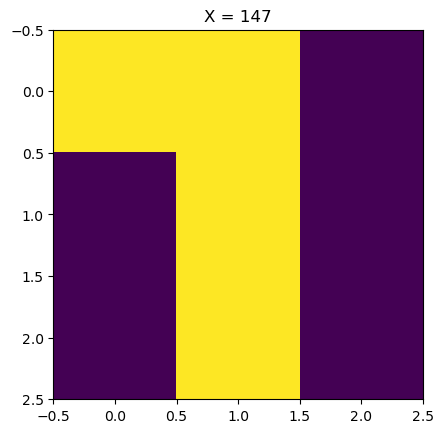

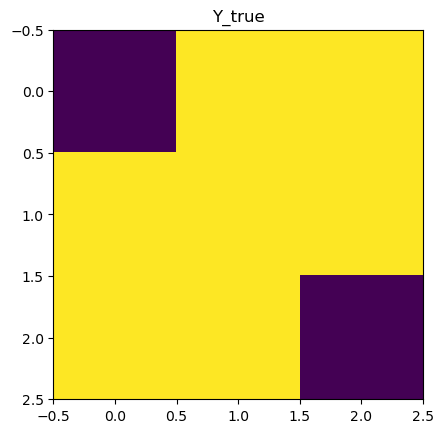

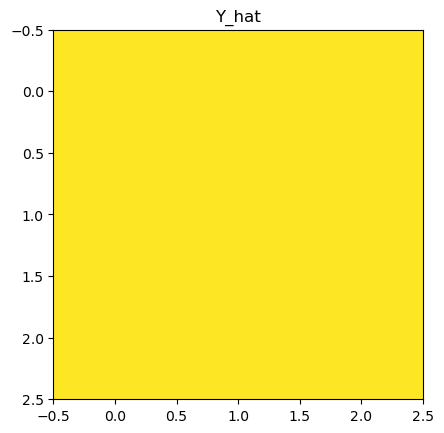

In [124]:
## EXAMPLE
x = np.random.choice(2**9, p=Px)
# x =42
y_true = np.argmax(Py[x])
y_hat = h(x)

plt.imshow(int2img(x), vmin=0, vmax=1)
plt.title(f'X = {x}')
plt.show()
plt.imshow(int2img(y_true), vmin=0, vmax=1)
plt.title('Y_true')
plt.show()

plt.imshow(int2img(y_hat), vmin=0, vmax=1)
plt.title('Y_hat')
plt.show()

### Losses

In [13]:
# for plot_loss in [plot_01_loss, plot_accuracy_loss, plot_voldiff_loss, plot_quadvoldiff_loss, plot_dice_loss]:
#     plot_loss(h, Px, Py, hatPyi)

/home/bruno-pacheco/synthetic-selective-segmentation/src/risks.py:45: RuntimeWarning: invalid value encountered in scalar divide
  return lambda x: 1 - 2 * np.sum(hatPyi[x] * int2img(h(x))) / (hatPyi[x].sum() + int2img(h(x)).sum())


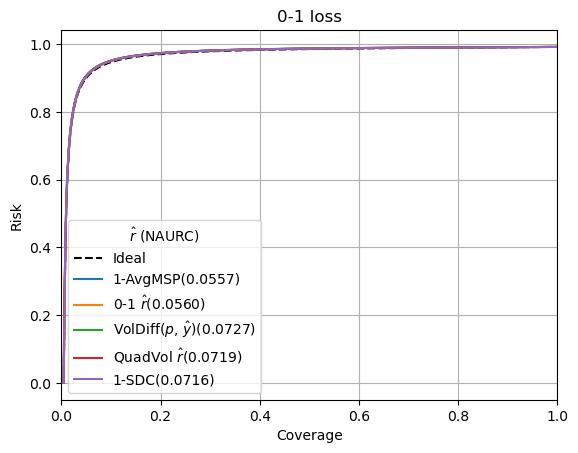

/home/bruno-pacheco/synthetic-selective-segmentation/src/risks.py:45: RuntimeWarning: invalid value encountered in scalar divide
  return lambda x: 1 - 2 * np.sum(hatPyi[x] * int2img(h(x))) / (hatPyi[x].sum() + int2img(h(x)).sum())


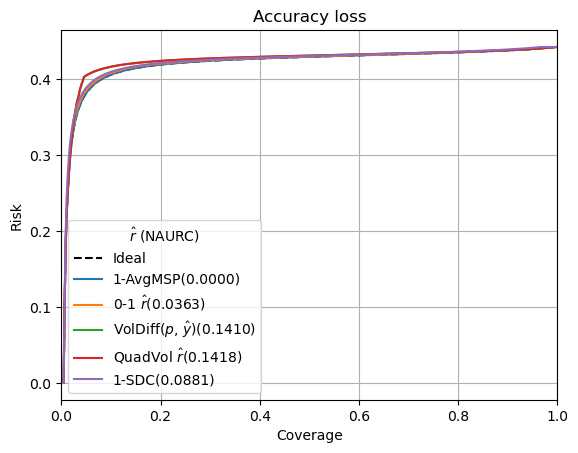

KeyboardInterrupt: 

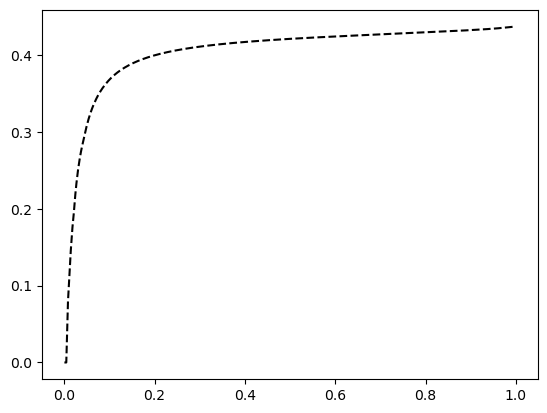

In [123]:
for plot_rc in [plot_01_rc, plot_accuracy_rc, plot_voldiff_rc, plot_quadvoldiff_rc, plot_dice_rc]:
    plot_rc(h, Px, Py, hatPyi)